# **Extracting Information from Legal Documents Using RAG**

## **Objective**

The main objective of this assignment is to process and analyse a collection text files containing legal agreements (e.g., NDAs) to prepare them for implementing a **Retrieval-Augmented Generation (RAG)** system. This involves:

* Understand the Cleaned Data : Gain a comprehensive understanding of the structure, content, and context of the cleaned dataset.
* Perform Exploratory Analysis : Conduct bivariate and multivariate analyses to uncover relationships and trends within the cleaned data.
* Create Visualisations : Develop meaningful visualisations to support the analysis and make findings interpretable.
* Derive Insights and Conclusions : Extract valuable insights from the cleaned data and provide clear, actionable conclusions.
* Document the Process : Provide a detailed description of the data, its attributes, and the steps taken during the analysis for reproducibility and clarity.

The ultimate goal is to transform the raw text data into a clean, structured, and analysable format that can be effectively used to build and train a RAG system for tasks like information retrieval, question-answering, and knowledge extraction related to legal agreements.

### **Business Value**  


The project aims to leverage RAG to enhance legal document processing for businesses, law firms, and regulatory bodies. The key business objectives include:

* Faster Legal Research: <br> Reduce the time lawyers and compliance officers spend searching for relevant case laws, precedents, statutes, or contract clauses.
* Improved Contract Analysis: <br> Automatically extract key terms, obligations, and risks from lengthy contracts.
* Regulatory Compliance Monitoring: <br> Help businesses stay updated with legal and regulatory changes by retrieving relevant legal updates.
* Enhanced Decision-Making: <br> Provide accurate and context-aware legal insights to assist in risk assessment and legal strategy.


**Use Cases**
* Legal Chatbots
* Contract Review Automation
* Tracking Regulatory Changes and Compliance Monitoring
* Case Law Analysis of past judgments
* Due Diligence & Risk Assessment

## **1. Data Loading, Preparation and Analysis** <font color=red> [20 marks] </font><br>

### **1.1 Data Understanding**

The dataset contains legal documents and contracts collected from various sources. The documents are present as text files (`.txt`) in the *corpus* folder.

There are four types of documents in the *courpus* folder, divided into four subfolders.
- `contractnli`: contains various non-disclosure and confidentiality agreements
- `cuad`: contains contracts with annotated legal clauses
- `maud`: contains various merger/acquisition contracts and agreements
- `privacy_qa`: a question-answering dataset containing privacy policies

The dataset also contains evaluation files in JSON format in the *benchmark* folder. The files contain the questions and their answers, along with sources. For each of the above four folders, there is a `json` file: `contractnli.json`, `cuad.json`, `maud.json` `privacy_qa.json`. The file structure is as follows:

```
{
    "tests": [
        {
            "query": <question1>,
            "snippets": [{
                    "file_path": <source_file1>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 1>
                },
                {
                    "file_path": <source_file2>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 2>
                }, ....
            ]
        },
        {
            "query": <question2>,
            "snippets": [{<answer context for que 2>}]
        },
        ... <more queries>
    ]
}
```

### **1.2 Load and Preprocess the data** <font color=red> [5 marks] </font><br>

#### Loading libraries

In [1]:
## The following libraries might be useful
# !pip install evaluate
# !pip install -q langchain-openai
# !pip install -U -q langchain-community
# !pip install -U -q langchain-chroma
# !pip install -U -q datasets
# !pip install -U -q ragas
# !pip install -U -q rouge_score

# import nltk
# nltk.download('punkt')
# nltk.download('stopwords')

In [40]:
# %%
# import essential libraries
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random
import shutil
from pathlib import Path
import evaluate as hf_evaluate # For BLEU score (aliased)

random.seed(42) 
import warnings
warnings.filterwarnings('ignore')

# Langchain imports
from langchain.schema import Document  # optional, for type clarity
from langchain.document_loaders import DirectoryLoader, TextLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.prompts import PromptTemplate
from langchain_openai import OpenAIEmbeddings
# from langchain_chroma import Chroma
from langchain_community.vectorstores import Chroma
from langchain_openai import ChatOpenAI
from langchain.chains import RetrievalQA
from langchain.docstore.document import Document
# from pathlib import Path # Already imported

# NLTK for text processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

# scikit-learn for TF-IDF and similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Evaluation libraries
from rouge_score import rouge_scorer

from datasets import Dataset # For RAGAS
from tqdm import tqdm
nltk.data.find('tokenizers/punkt')
nltk.data.find('corpora/stopwords')

from string import punctuation
stop_words = list(set(stopwords.words('english')))+list(set(punctuation))

from ragas import evaluate as ragas_evaluate # For RAGAS (aliased)
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_recall,
    context_precision,
    answer_correctness
)

from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

#### **1.2.1** <font color=red> [3 marks] </font>
Load all `.txt` files from the folders.

You can utilise document loaders from the options provided by the LangChain community.

Optionally, you can also read the files manually, while ensuring proper handling of encoding issues (e.g., utf-8, latin1). In such case, also store the file content along with metadata (e.g., file name, directory path) for traceability.

In [3]:
# Load the files as documents
def load_all_text(dir_path):

    corpus_path = Path(dir_path)
    all_documents = []

    # Create list object of .txt files
    txt_files = [f for f in corpus_path.rglob("*.txt") if not f.name.startswith("._")]

    for file_path in txt_files:
        loader = TextLoader(str(file_path), autodetect_encoding=True)
        docs = loader.load()
        
        if not docs:
            continue

        for doc in docs:
            if not doc.page_content.strip():
                # skip empty content
                continue

            # useful metadata for tracking
            doc.metadata['filename'] = file_path.name
            # store relative path from corpus root
            doc.metadata['relative_path'] = str(file_path.relative_to(corpus_path))
            doc.metadata['file_path'] = str(file_path)

            all_documents.append(doc)

    print("Created a single corpus successfully.")
    return all_documents

In [4]:
dir_path = 'C:\\Users\\DELL\\Downloads\\RAG Assignment\\rag_legal\\corpus\\'
documents = load_all_text(dir_path)

Created a single corpus successfully.


#### **1.2.2** <font color=red> [2 marks] </font>
Preprocess the text data to remove noise and prepare it for analysis.

Remove special characters, extra whitespace, and irrelevant content such as email and telephone contact info.
Normalise text (e.g., convert to lowercase, remove stop words).
Handle missing or corrupted data by logging errors and skipping problematic files.

In [5]:
# Clean and preprocess the data
def clean_preprocess_text(documents):
    clean_documents = []
    for doc in documents:
        # remove special characters
        text = re.sub(r'[^\w\s\.\,\;\:\!\?\(\)\"\'\-\$\€\£\¥§%©®]', ' ', doc.page_content)
    
        #remove extra space
        text = re.sub(r'[ \t\f\v\r]+', ' ', text)
    
        #remove email and telephone contact
        text=re.sub(r'\S*@\S*\s?', "", text)
        text=re.sub(r'(123).456.7899', "", text)
    
        #lower case
        text = text.lower()
    
        good_words = []
        for sent in sent_tokenize(text):
            for word in word_tokenize(sent):
                if word not in stop_words:
                    good_words.append(word)
        text = ' '.join(good_words)                

        # retain original metadata
        clean_doc = type(doc)(
            page_content=text.strip(),
            metadata=doc.metadata
        )

        clean_documents.append(clean_doc)
    
    return clean_documents


In [6]:
cleaned_documents = clean_preprocess_text(documents)

### **1.3 Exploratory Data Analysis** <font color=red> [10 marks] </font><br>

#### **1.3.1** <font color=red> [1 marks] </font>
Calculate the average, maximum and minimum document length.

In [7]:
# Calculate the average, maximum and minimum document length.
def document_length_calc(documents):
    doc_lengths = [len(doc.page_content) for doc in documents]
    
    avg_length = np.mean(doc_lengths)
    max_length = np.max(doc_lengths)
    min_length = np.min(doc_lengths)
    
    print("Average Length:", avg_length,"Maximum Length:",max_length,"Minimum Length:",min_length)

In [8]:
document_length_calc(cleaned_documents)

Average Length: 73693.62320916905 Maximum Length: 695963 Minimum Length: 1133


In [9]:
document_length_calc(documents)

Average Length: 105025.15759312321 Maximum Length: 999235 Minimum Length: 1660


#### **1.3.2** <font color=red> [4 marks] </font>
Analyse the frequency of occurrence of words and find the most and least occurring words.

Find the 20 most common and least common words in the text. Ignore stop words such as articles and prepositions.

In [10]:
# Find frequency of occurence of words
def twenty_words(docs):
    
    all_words = []
    for doc in docs:
        tokens = word_tokenize(doc.page_content)
        filtered_tokens = []
        for word in tokens:
            if word.isalpha() and word.lower() not in stop_words and len(word) > 2:
                filtered_tokens.append(word)
        all_words.extend(filtered_tokens)

    word_counts = Counter(all_words)
    most_common_words = word_counts.most_common(20)
    least_common_words = sorted(word_counts.items(), key=lambda item: item[1])[:20]

    print("Top 20 most occuring Words excluding stop words:")
    print("-"*20)
    for word, count in most_common_words:
        print(word,": ",count)
    print("-"*50)
    print("Top 20 least occuring Words excluding stop words:")
    print("-"*20)
    for word, count in least_common_words:
        print(word,": ",count)

In [11]:
twenty_words(cleaned_documents)

Top 20 most occuring Words excluding stop words:
--------------------
company :  156124
shall :  108016
agreement :  104635
section :  75352
parent :  60660
party :  53097
date :  39338
time :  35435
material :  34213
merger :  33850
subsidiaries :  33320
applicable :  31371
including :  29403
respect :  28848
may :  28069
stock :  26647
information :  25714
parties :  24617
business :  23545
prior :  23341
--------------------------------------------------
Top 20 least occuring Words excluding stop words:
--------------------
monnaie :  1
candidacy :  1
grateful :  1
frédéric :  1
sohet :  1
koen :  1
gerven :  1
cvba :  1
coöperatieve :  1
vennootschap :  1
beperkte :  1
aansprakelijkheid :  1
coopérative :  1
rpr :  1
brussel :  1
bruxelles :  1
kredbebb :  1
tohmatsu :  1
maidenhead :  1
pls :  1


#### **1.3.3** <font color=red> [4 marks] </font>
Analyse the similarity of different documents to each other based on TF-IDF vectors.

Transform some documents to TF-IDF vectors and calculate their similarity matrix using a suitable distance function. If contracts contain duplicate or highly similar clauses, similarity calculation can help detect them.

Identify for the first 10 documents and then for 10 random documents. What do you observe?

In [12]:
# Transform the page contents of documents
def analyze_document_similarity_tfidf(docs, indices = [],title_text = ""):
    sample_docs = []
    doc_labels = []
    
    if len(indices) == 0:
        sample_docs = [doc.page_content for doc in docs[:10]]
        for i in range(10):
            doc_labels.append("Doc "+str(i))
    else:
        sample_docs = [docs[i].page_content for i in indices]
        for i in indices:
            doc_labels.append("Doc "+str(i))
    # Compute similarity scores
    # initialize TF-IDF Vectorizer
    vectorizer = TfidfVectorizer(stop_words=stop_words, max_features=5000, min_df=2, max_df=0.95)
    tfidf_matrix = vectorizer.fit_transform(sample_docs)
    # similarity matrix
    similarity_matrix = cosine_similarity(tfidf_matrix)

    # plot similarity matrix
    plt.figure(figsize=(6, 6))
    sns.heatmap(similarity_matrix, annot=True, cmap="viridis", fmt=".2f",xticklabels=doc_labels, yticklabels=doc_labels)
    plt.title(f'TF-IDF Document Similarity Matrix - {title_text}')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    

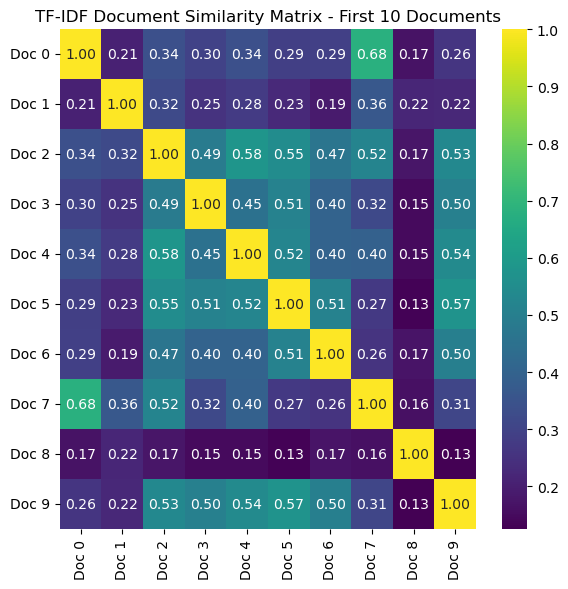

In [13]:
# similarity scores for first 10 documents
analyze_document_similarity_tfidf(cleaned_documents, indices = [],title_text='First 10 Documents')

**Observations: First 10 Documents**

There are clusters of high similarity, indicating presence of similar words.
*   Highest similarity exists between the Doc0, and Doc7, at 0.68.
*   Doc9 similarity score is >= 0.5 and <=0.6 for Doc2,3,4,5, and 6
*   There is a cluster of similarity between Doc4,5,6, and 7. Most of the interaction have similarity >= 0.5 and <=0.6.


In [14]:
# create a list of 10 random integers
random_indices = random.sample(list(range(len(cleaned_documents))),10)

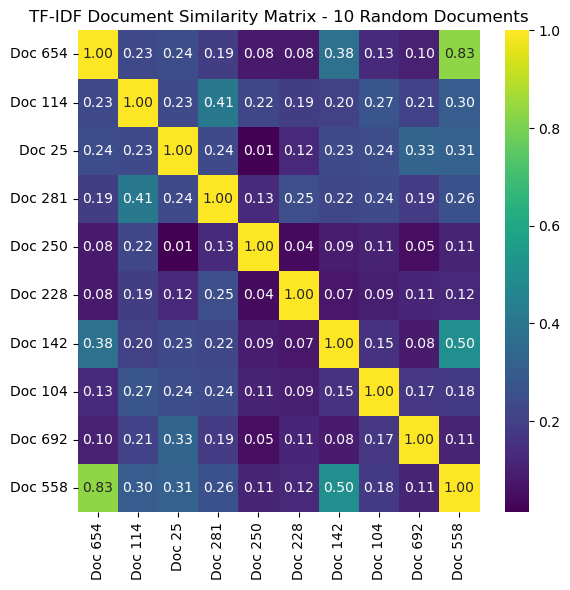

In [15]:
# Compute similarity scores for 10 random documents
analyze_document_similarity_tfidf(cleaned_documents, indices = random_indices,title_text='10 Random Documents')

**Observations: First 10 Documents**

There is one document with very high similarity, one with 0.83 similarity. Rest of the documents have very low similarity. This indicates, it is possible to overlap between few documents, whereas most of the documents may not be similar. This implies, there is very less chance of having duplicates.
*   Highest similarity exists between the Doc558, and Doc654, at 0.83.
*   Doc558 has similarity score 0.5 for Doc142

### **1.4 Document Creation and Chunking** <font color=red> [5 marks] </font><br>

#### **1.4.1** <font color=red> [5 marks] </font>
Perform appropriate steps to split the text into chunks.

In [16]:
# Process files and generate chunks
def document_chunks(documents):
    #define text splitter
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200
    )

    all_chunks = []
    for _, doc in enumerate(documents):
        # chunk clean text
        chunks_from_doc = text_splitter.split_documents([doc]) 

        for chunk_id, chunk in enumerate(chunks_from_doc):
            #clean text and update metadata
            chunk_content = chunk.page_content.strip()             
            chunk.metadata['filename'] = doc.metadata.get('filename', 'Unknown')
            chunk.metadata['chunk_number'] = chunk_id + 1
            chunk.metadata['total_chunks_in_doc'] = len(chunks_from_doc)
            #append chunk to master list
            all_chunks.append(chunk)
        
    return all_chunks

In [17]:
all_chunks = document_chunks(cleaned_documents)

## **2. Vector Database and RAG Chain Creation** <font color=red> [15 marks] </font><br>

### **2.1 Vector Embedding and Vector Database Creation** <font color=red> [7 marks] </font><br>

#### **2.1.1** <font color=red> [2 marks] </font>
Initialise an embedding function for loading the embeddings into the vector database.

Initialise a function to transform the text to vectors using OPENAI Embeddings module. You can also use this function to transform during vector DB creation itself.

In [18]:
# Fetch your OPENAI API Key as an environment variable
openai_api_key = os.getenv("OPENAI_API_KEY")

In [19]:
# initialise an embedding function
def get_openai_embeddings(api_key):
    embeddings_model = OpenAIEmbeddings(
        openai_api_key=api_key,
        model="text-embedding-3-small"
    )
    return embeddings_model

In [20]:
# initialize the embedding function
embeddings_function = get_openai_embeddings(openai_api_key)

#### **2.1.2** <font color=red> [5 marks] </font>
Load the embeddings to a vector database.

Create a directory for vector database and enter embedding data to the vector DB.

In [21]:
# Add Chunks to vector DB
def chroma_db_cache(chunks,embedding_func,db_path,load_existing = True):
    # load existing db
    if Path(db_path).exists() and load_existing:
        vector_db = Chroma(persist_directory=db_path, embedding_function=embedding_func)
        print("loaded existing vector db.")
        return vector_db

    elif Path(db_path).exists():
        shutil.rmtree(db_path)
        vector_db = Chroma.from_documents(
            documents=chunks,
            embedding=embedding_func,
            persist_directory=db_path
        )
        vector_db.persist()
        print(f"created vector db with {len(chunks)} chunks.")
        return vector_db

In [22]:
# True to load existing
use_existing_db = True

# define path for vector database
vector_db_directory = "C:\\Users\\DELL\\Downloads\\model\\"

# create or load the vector database
if document_chunks and embeddings_function:
    vector_database = chroma_db_cache(
        chunks=all_chunks,
        embedding_func=embeddings_function,
        db_path=vector_db_directory,
        load_existing=use_existing_db
    )
else:
    print("skipping vector database creation due to missing chunks or embedding function.")
    vector_database = None

C:\Users\DELL\AppData\Local\Temp\ipykernel_7532\189297756.py:5: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vector_db = Chroma(persist_directory=db_path, embedding_function=embedding_func)


loaded existing vector db.


### **2.2 Create RAG Chain** <font color=red> [8 marks] </font><br>

#### **2.2.1** <font color=red> [5 marks] </font>
Create a RAG chain.

In [23]:
# Create a RAG chain
def create_rag_chain(db, llm_api_key, k_retriever = 3, llm_model_name = "gpt-4.1-mini"):
    
    # Use the passed llm_model_name or a default
    llm = ChatOpenAI(model_name=llm_model_name, openai_api_key=llm_api_key, temperature=0.1)

    #retriever with k parameter
    retriever = db.as_retriever(
        search_type="similarity",
        search_kwargs={'k': k_retriever} 
    )

    # Prompt Template for Legal Documents
    prompt_template = """
    You are a legal assistant who specializes in analyzing legal documents.
    Use the following pieces of context to answer the question at the end.
    If you don't know the answer from the context provided, just say that you don't know, do not try to make up an answer.
    If the answer is found, be concise in your answer, without adding any fluff.
    Please quote the exact phrases from the context if they directly answer the question.

    Context:
    {context}

    Question: {question}

    Useful Answer:
    """
    QA_CHAIN_PROMPT = PromptTemplate.from_template(prompt_template)

    rag_qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=retriever,
        return_source_documents=True,
        chain_type_kwargs={"prompt": QA_CHAIN_PROMPT} # custom prompt
    )
    print("RAG chain created successfully with custom prompt.")
    return rag_qa_chain

In [24]:
# Initialize the RAG chain
rag_chain_instance = create_rag_chain(
    db=vector_database,
    llm_api_key=openai_api_key, 
)

RAG chain created successfully with custom prompt.


#### **2.2.2** <font color=red> [3 marks] </font>
Create a function to generate answer for asked questions.

Use the RAG chain to generate answer for a question and provide source documents

In [25]:
# Create a function for question answering
def get_answer_from_rag(chain, query):

    #insert query
    response = chain.invoke({"query": query})
    #get answer
    answer = response.get("result", "No answer generated.")
    #get source document
    source_documents = response.get("source_documents", [])
    
    print(f"\nAnswer for your query:\n{answer}")
    
    if source_documents:
        print(f"\nSource Documents ({len(source_documents)} retrieved):")
        for i, doc_source in enumerate(source_documents):
            print(f"  --- Source {i+1} ---")
            # Use the 'filename' key that Langchain natively carries
            print(f"  Filename: {doc_source.metadata.get('filename', 'N/A')}")
            # Use 'relative_path' for directory information
            print(f"  Directory: {doc_source.metadata.get('relative_path', 'N/A')}")
            print(f"  Chunk Num: {doc_source.metadata.get('chunk_number', 'N/A')}")

    else:
        print("  No source documents were returned.")
        
    return answer, source_documents

In [26]:
# Example question
question ="Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?"
# question = "What does an NDA usually entail?"
# example query

generated_answer, source_docs = get_answer_from_rag(rag_chain_instance, question)


Answer for your query:
Yes, the document states: "8. license nothing agreement intended grant" indicating the Agreement does not grant the Receiving Party any rights to the Confidential Information.

Source Documents (3 retrieved):
  --- Source 1 ---
  Filename: thoughtbot-mutual-nda.txt
  Directory: contractnli\thoughtbot-mutual-nda.txt
  Chunk Num: 4
  --- Source 2 ---
  Filename: NCDG_Non-disclosure-agreement.txt
  Directory: contractnli\NCDG_Non-disclosure-agreement.txt
  Chunk Num: 7
  --- Source 3 ---
  Filename: MutualNDA_The_Knights_of_Unity.txt
  Directory: contractnli\MutualNDA_The_Knights_of_Unity.txt
  Chunk Num: 4


## **3. RAG Evaluation** <font color=red> [10 marks] </font><br>

### **3.1 Evaluation and Inference** <font color=red> [10 marks] </font><br>

#### **3.1.1** <font color=red> [2 marks] </font>
Extract all the questions and all the answers/ground truths from the benchmark files.

Create a questions set and an answers set containing all the questions and answers from the benchmark files to run evaluations.

In [35]:
# Create a question set by taking all the questions from the benchmark data
# Also create a ground truth/answer set
def load_benchmark_qna(benchmark_dir_path = "benchmark"):
    """
    loads questions and their corresponding ground truth answers from JSON benchmark files.
    each question can have multiple ground truth snippets/answers.
    returns:
        - list of questions (queries).
        - list of lists of ground truth answers (one list of answers per question).
    """
    benchmark_path = Path(benchmark_dir_path)
    all_queries = []
    all_ground_truth_sets = [] # list of lists, as one query can have multiple GT answers

    benchmark_files = ["contractnli.json", "cuad.json", "maud.json", "privacy_qa.json"]
    
    print(f"Loading benchmark data from: {benchmark_path}")

    for file_name in benchmark_files:
        file_path = benchmark_path / file_name
        if not file_path.exists():
            print(f"Benchmark file not found: {file_path}. Skipping.")
            continue
        
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            num_tests_in_file = 0
            for test_case in data.get("tests", []):
                query = test_case.get("query")
                snippets = test_case.get("snippets", [])
                
                current_ground_truths = [s.get("answer", "").strip() for s in snippets if s.get("answer", "").strip()]
                
                if query and current_ground_truths: # Only add if query and some GT answers exist
                    all_queries.append(query)
                    all_ground_truth_sets.append(current_ground_truths)
                    num_tests_in_file += 1
            print(f"Loaded {num_tests_in_file} valid Q&A pairs from {file_name}.")
        except json.JSONDecodeError:
            print(f"Error decoding JSON from {file_path}. Skipping.")
        except Exception as e:
            print(f"An unexpected error occurred with {file_path}: {e}. Skipping.")
            
    print(f"\nTotal questions loaded for evaluation: {len(all_queries)}")
    print(f"Total sets of ground truth answers loaded: {len(all_ground_truth_sets)}")
    
    return all_queries, all_ground_truth_sets

In [36]:
# load benchmark data
benchmark_data_directory = "C:\\Users\\DELL\\Downloads\\RAG Assignment\\rag_legal\\benchmarks\\"
evaluation_questions, evaluation_ground_truths = load_benchmark_qna(benchmark_data_directory)

# verify loaded data
if evaluation_questions and evaluation_ground_truths:
    print(f"\nSample benchmark data (first Q&A):")
    print(f"Question 1: {evaluation_questions[0]}")
    print(f"Ground Truths for Q1: {evaluation_ground_truths[0]}")
else:
    print("No benchmark data loaded. Evaluation cannot proceed.")

Loading benchmark data from: C:\Users\DELL\Downloads\RAG Assignment\rag_legal\benchmarks
Loaded 977 valid Q&A pairs from contractnli.json.
Loaded 4042 valid Q&A pairs from cuad.json.
Loaded 1676 valid Q&A pairs from maud.json.
Loaded 194 valid Q&A pairs from privacy_qa.json.

Total questions loaded for evaluation: 6889
Total sets of ground truth answers loaded: 6889

Sample benchmark data (first Q&A):
Question 1: Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?
Ground Truths for Q1: ['Any and all proprietary rights, including but not limited to rights to and in inventions, patent rights, utility models, copyrights, trademarks and trade secrets, in and to any Confidential Information shall be and remain with the Participants respectively, and Mentor shall not have any right, license, title or interest in or to any Confidential Information, exc

#### **3.1.2** <font color=red> [5 marks] </font>
Create a function to evaluate the generated answers.

Evaluate the responses on *Rouge*, *Ragas* and *Bleu* scores.

In [37]:
# Function to evaluate the RAG pipeline
# evaluate the RAG pipeline
def calculate_evaluation_scores(generated_answers, 
                                ground_truth_sets):
    """
    calculates ROUGE and BLEU scores for generated answers against ground truth sets.
    for ROUGE, it compares the generated answer against a concatenated string of all ground truths for that question.
    for BLEU, it compares the generated answer against the list of individual ground truth answers.
    """
    if not generated_answers or not ground_truth_sets or len(generated_answers) != len(ground_truth_sets):
        print("Mismatch in lengths of generated answers and ground truth sets for ROUGE/BLEU, or lists are empty.")
        return {"rouge1_f1": 0, "rouge2_f1": 0, "rougeL_f1": 0, "bleu": 0}

    rouge_metrics = ['rouge1', 'rouge2', 'rougeL']
    rouge_calc = rouge_scorer.RougeScorer(rouge_metrics, use_stemmer=True)
    
    bleu_calc = None # Initialize
    try:
        bleu_calc = hf_evaluate.load('bleu') # <<< USE ALIASED hf_evaluate
        print("BLEU metric loaded successfully from Hugging Face evaluate.")
    except Exception as e:
        print(f"Could not load BLEU metric from Hugging Face evaluate: {e}. BLEU scores will be 0.")
        # bleu_calc remains None

    all_rouge_f1 = {metric: [] for metric in rouge_metrics}
    all_bleu = []

    print(f"Calculating ROUGE and BLEU scores for {len(generated_answers)} responses...")
    for gen_ans, gt_list in tqdm(zip(generated_answers, ground_truth_sets), total=len(generated_answers), desc="Evaluating ROUGE/BLEU"):
        
        current_gen_ans = str(gen_ans) if gen_ans is not None else ""
        
        # For ROUGE
        current_gt_list_for_rouge = [str(g) for g in gt_list if g is not None] if gt_list else [""]
        concatenated_gt = " ".join(current_gt_list_for_rouge)
        
        if not gt_list: # If no ground truths for this question, effectively
            for metric in rouge_metrics: all_rouge_f1[metric].append(0)
            if bleu_calc: all_bleu.append(0)
            continue
        
        try:
            rouge_scores = rouge_calc.score(concatenated_gt, current_gen_ans)
            for metric in rouge_metrics:
                all_rouge_f1[metric].append(rouge_scores[metric].fmeasure)
        except Exception as e:
            print(f"Error calculating ROUGE for a response: {e}")
            for metric in rouge_metrics: all_rouge_f1[metric].append(0)
            
        # For BLEU
        if bleu_calc:
            try:
                # BLEU expects a list of reference strings for each prediction
                current_gt_list_for_bleu = [[str(g) for g in gt_list if g is not None]] if any(g is not None for g in gt_list) else [[""]]
                predictions_for_bleu = [current_gen_ans]
                
                bleu_result = bleu_calc.compute(predictions=predictions_for_bleu, references=current_gt_list_for_bleu)
                all_bleu.append(bleu_result['bleu'])
            except Exception as e:
                print(f"Error calculating BLEU for a response: {e}")
                all_bleu.append(0)
        else:
            all_bleu.append(0) # If bleu_calc is None

    avg_scores = {}
    for metric in rouge_metrics:
        avg_scores[f"{metric}_f1"] = np.mean(all_rouge_f1[metric]) if all_rouge_f1[metric] else 0
    
    avg_scores["bleu"] = np.mean(all_bleu) if all_bleu else 0

    print("\n--- Evaluation Metrics Summary (ROUGE/BLEU) ---")
    for metric_name, score_val in avg_scores.items():
        print(f"  Average {metric_name.replace('_f1', ' F1').upper()}: {score_val:.4f}")
    print("----------------------------------")
    
    return avg_scores

#### **3.1.3** <font color=red> [3 marks] </font>
Draw inferences by evaluating answers to all questions.

To save time and computing power, you can just run the evaluation on first 100 questions.

In [41]:
# Evaluate the RAG pipeline
def perform_full_evaluation(rag_pipeline,
                            questions_list,
                            ground_truth_answers_list,
                            max_questions_to_eval = 100,
                            ragas_llm = None, 
                            ragas_embeddings = None
                           ):
    """
    Runs the full evaluation pipeline: ROUGE, BLEU, and RAGAS.
    """
    if not rag_pipeline:
        print("RAG pipeline is not initialized. Cannot perform evaluation.")
        return None, None
    if not questions_list: # check if the list itself is None or empty
        print("Evaluation questions are missing or empty.")
        return None, None
    if not ground_truth_answers_list: # check if the list itself is None or empty
        print("Evaluation ground truths are missing or empty.")
        return None, None
    
    num_available_questions = len(questions_list)
    actual_eval_count = min(max_questions_to_eval, num_available_questions)

    if actual_eval_count == 0:
        print("No questions available for evaluation after limiting (actual_eval_count is 0).")
        return None, None

    print(f"Starting full evaluation for {actual_eval_count} questions (out of {num_available_questions} available).")

    current_eval_questions = questions_list[:actual_eval_count]
    current_eval_ground_truths_lists = ground_truth_answers_list[:actual_eval_count]

    generated_answers_for_eval = []
    ragas_eval_data = {"question": [], "answer": [], "contexts": [], "ground_truth": []}

    print("Generating RAG answers and preparing data for all evaluations...")
    for i, query_text in enumerate(tqdm(current_eval_questions, desc="Generating RAG answers")):
        ans_text, source_docs = get_answer_from_rag(rag_pipeline, query_text)
        
        generated_ans = str(ans_text) if ans_text is not None else ""
        generated_answers_for_eval.append(generated_ans)

        ragas_eval_data["question"].append(str(query_text))
        ragas_eval_data["answer"].append(generated_ans)
        contexts = [str(doc.page_content) for doc in source_docs] if source_docs else []
        ragas_eval_data["contexts"].append(contexts)
        gt_for_ragas = str(current_eval_ground_truths_lists[i][0]) if current_eval_ground_truths_lists[i] and current_eval_ground_truths_lists[i][0] is not None else ""
        ragas_eval_data["ground_truth"].append(gt_for_ragas)

        if i < 3: # print samples
            print(f"\n--- Eval Sample Q&A ({i+1}/{actual_eval_count}) ---")
            print(f"  Question: {query_text}")
            print(f"  Generated Answer: {generated_ans}")
            print(f"  Retrieved Contexts (first 50 chars each): {[c[:50]+'...' for c in contexts]}")
            print(f"  Ground Truths (original list): {current_eval_ground_truths_lists[i]}")
            print(f"  Ground Truth (for RAGAS): {gt_for_ragas}")
            print("---------------------------------------\n")

    # calculate ROUGE and BLEU scores using the dedicated function
    print("\nCalculating ROUGE and BLEU scores...")
    rouge_bleu_scores = calculate_evaluation_scores(generated_answers_for_eval, current_eval_ground_truths_lists)

    # Calculate RAGAS scores
    ragas_scores_dict = None
    if ragas_llm: # Proceed only if RAGAS LLM is available
        print("\nCalculating RAGAS scores...")
        try:
            ragas_dataset = Dataset.from_dict(ragas_eval_data)
            metrics_to_evaluate = [faithfulness, answer_relevancy, context_precision, context_recall, answer_correctness]
            
            results = ragas_evaluate(
                dataset=ragas_dataset,
                metrics=metrics_to_evaluate,
                llm=ragas_llm,
                embeddings=ragas_embeddings
            )
            ragas_scores_dict = results 
            print("\n--- RAGAS Metrics Summary ---")
            print(ragas_scores_dict) # print the raw result object/dictionary
            print("-----------------------------")
        except Exception as e:
            print(f"Error during RAGAS evaluation: {e}")
            ragas_scores_dict = {"error": str(e)} # store error info
    else:
        print("Skipping RAGAS evaluation as RAGAS LLM was not provided (e.g., API key issue or failed init).")
        ragas_scores_dict = {"status": "skipped_no_llm"}

    return rouge_bleu_scores, ragas_scores_dict

In [42]:
openai_api_key = os.getenv("OPENAI_API_KEY")

ragas_eval_llm_model_name = "gpt-4.1-mini"
ragas_eval_llm = None
ragas_eval_embeddings = None

if openai_api_key:
    try:
        ragas_eval_llm = ChatOpenAI(model_name=ragas_eval_llm_model_name, openai_api_key=openai_api_key, temperature=0)
        ragas_eval_embeddings = OpenAIEmbeddings(openai_api_key=openai_api_key, model="text-embedding-3-small")
        print(f"RAGAS LLM ({ragas_eval_llm_model_name}) and Embeddings initialized.")
    except Exception as e:
        print(f"Error initializing RAGAS LLM/Embeddings: {e}. RAGAS will be skipped.")
        ragas_eval_llm = None 
else:
    print("CRITICAL: OpenAI API Key not found. RAGAS evaluation will be skipped.")

NUM_QUESTIONS_FOR_OVERALL_EVAL = 100 # adjust as needed

# check readiness for final evaluation
ready_for_final_eval = True
final_rouge_bleu_metrics = None
final_ragas_result_object = None

try:

    if not rag_chain_instance: ready_for_final_eval = False; print("Skipping: `rag_chain_instance` not available.")
    if not evaluation_questions: ready_for_final_eval = False; print("Skipping: `evaluation_questions` not available.")
    if not evaluation_ground_truths: ready_for_final_eval = False; print("Skipping: `evaluation_ground_truths` not available.")
except NameError as e:
    print(f"Skipping final evaluation: A key variable ('{e.name}') was not defined. Please run all prerequisite cells.")
    ready_for_final_eval = False

if not ragas_eval_llm: 
    print("Note: RAGAS part of the evaluation will be skipped as its LLM is not available.")

# perform Evaluation ---
if ready_for_final_eval:
    print(f"\nInitiating RAG pipeline evaluation on up to {NUM_QUESTIONS_FOR_OVERALL_EVAL} question(s).")
    
    final_rouge_bleu_metrics, final_ragas_result_object = perform_full_evaluation(
        rag_pipeline=rag_chain_instance,
        questions_list=evaluation_questions,
        ground_truth_answers_list=evaluation_ground_truths,
        max_questions_to_eval=NUM_QUESTIONS_FOR_OVERALL_EVAL,
        ragas_llm=ragas_eval_llm, 
        ragas_embeddings=ragas_eval_embeddings
    )

    # print ROUGE/BLEU Results ---
    if final_rouge_bleu_metrics:
        print("\n" + "="*60)
        print("OVERALL RAG PIPELINE - ROUGE/BLEU SUMMARY")
        print("="*60)
        actual_eval_count_display = min(NUM_QUESTIONS_FOR_OVERALL_EVAL, len(evaluation_questions) if evaluation_questions else 0)
        print(f"Evaluated on: {actual_eval_count_display} questions")
        for metric_name, score_value in final_rouge_bleu_metrics.items():
            print(f"  Average {metric_name.replace('_f1', ' F1').upper()}: {score_value:.4f}")
        print("="*60)
        
    # print RAGAS Results ---
    if final_ragas_result_object:
        actual_eval_count_display = min(NUM_QUESTIONS_FOR_OVERALL_EVAL, len(evaluation_questions) if evaluation_questions else 0)
        if isinstance(final_ragas_result_object, dict) and "error" in final_ragas_result_object:
            print("\n" + "="*60)
            print("RAGAS EVALUATION ERROR")
            print(f"Error details: {final_ragas_result_object['error']}")
            print("="*60)
        elif isinstance(final_ragas_result_object, dict) and "status" in final_ragas_result_object and final_ragas_result_object["status"] == "skipped_no_llm":
            print("\n" + "="*60)
            print("RAGAS EVALUATION SKIPPED (No LLM or API Key issue for RAGAS)")
            print("="*60)
        # Check if it's the RAGAS EvaluationResult object or a dict of scores
        elif hasattr(final_ragas_result_object, 'scores') or isinstance(final_ragas_result_object, dict):
            print("\n" + "="*60)
            print("OVERALL RAG PIPELINE - RAGAS SUMMARY")
            print("="*60)
            print(f"Evaluated on: {actual_eval_count_display} questions")
            
            scores_to_print = {}
            if hasattr(final_ragas_result_object, 'to_dict'): 
                 scores_to_print = final_ragas_result_object.to_dict()
            elif isinstance(final_ragas_result_object, dict): 
                 scores_to_print = final_ragas_result_object

            if scores_to_print:
                for metric_name, score_value in scores_to_print.items():
                    if isinstance(score_value, (float, np.floating, int)):
                        print(f"  Average {metric_name.replace('_', ' ').title()}: {score_value:.4f}")
            else:
                print("  RAGAS scores object could not be parsed into a printable dictionary.")
                print(f"  Raw RAGAS result: {final_ragas_result_object}")
            print("="*60)
        else:
            print("\n" + "="*60)
            print("RAGAS EVALUATION - UNKNOWN RESULT FORMAT")
            print(f"Raw RAGAS result: {final_ragas_result_object}")
            print("="*60)
else:
    print("\nFinal evaluation was not performed. Check logs above for reasons (e.g., missing variables, API key).")

RAGAS LLM (gpt-4.1-mini) and Embeddings initialized.

Initiating RAG pipeline evaluation on up to 100 question(s).
Starting full evaluation for 100 questions (out of 6889 available).
Generating RAG answers and preparing data for all evaluations...


Generating RAG answers:   1%|▌                                                         | 1/100 [00:01<03:07,  1.89s/it]


Answer for your query:
Yes. The document states, "nothing agreement intended grant" indicating the Agreement does not grant the Receiving Party any rights to the Confidential Information.

Source Documents (3 retrieved):
  --- Source 1 ---
  Filename: thoughtbot-mutual-nda.txt
  Directory: contractnli\thoughtbot-mutual-nda.txt
  Chunk Num: 4
  --- Source 2 ---
  Filename: NCDG_Non-disclosure-agreement.txt
  Directory: contractnli\NCDG_Non-disclosure-agreement.txt
  Chunk Num: 7
  --- Source 3 ---
  Filename: MutualNDA_The_Knights_of_Unity.txt
  Directory: contractnli\MutualNDA_The_Knights_of_Unity.txt
  Chunk Num: 4

--- Eval Sample Q&A (1/100) ---
  Question: Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?
  Generated Answer: Yes. The document states, "nothing agreement intended grant" indicating the Agreement does not grant the Receiving 

Generating RAG answers:   2%|█▏                                                        | 2/100 [00:05<04:26,  2.72s/it]


Answer for your query:
No. The document states that "confidential information include information already known independently developed mentor prior disclosure idea information already public domain wrongful act mentor information received third party free disclose information case doubt information deemed confidential information unless mentor proves information confidential," and also refers to "technical information" as a subset, but does not limit confidential information to only technical information.

Source Documents (3 retrieved):
  --- Source 1 ---
  Filename: CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt
  Directory: contractnli\CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt
  Chunk Num: 9
  --- Source 2 ---
  Filename: NDA-Artop-Inno-2017.txt
  Directory: contractnli\NDA-Artop-Inno-2017.txt
  Chunk Num: 2
  --- Source 3 ---
  Filename: CerenceInc_20191002_8-K_EX-10.4_11827494_EX-10.4_Intellectual Property Agreement.txt
  Directory: cuad\CerenceInc_20191002_8-K_EX-10.4_11827494_EX-10.4_I

...

Evaluating ROUGE/BLEU: 100%|████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 204.76it/s]



--- Evaluation Metrics Summary (ROUGE/BLEU) ---
  Average ROUGE1 F1: 0.2773
  Average ROUGE2 F1: 0.0714
  Average ROUGEL F1: 0.2005
  Average BLEU: 0.0000
----------------------------------

Calculating RAGAS scores...


Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[11]: IndexError(list index out of range)
ERROR:ragas.executor:Exception raised in Job[1]: IndexError(list index out of range)
ERROR:ragas.executor:Exception raised in Job[6]: IndexError(list index out of range)
ERROR:ragas.executor:Exception raised in Job[21]: IndexError(list index out of range)
ERROR:ragas.executor:Exception raised in Job[31]: IndexError(list index out of range)
ERROR:ragas.executor:Exception raised in Job[4]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[14]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[9]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[36]: IndexError(list index out of range)
ERROR:ragas.executor:Exception raised in Job[19]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[41]: IndexError(list index out of range)
ERROR:ragas.executor:Exception raised in Job[24]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[34]: TimeoutError()
ERROR:ragas.


--- RAGAS Metrics Summary ---
{'faithfulness': 0.9101, 'answer_relevancy': 0.5711, 'context_precision': 0.6574, 'context_recall': 0.5767, 'answer_correctness': 0.3211}
-----------------------------

OVERALL RAG PIPELINE - ROUGE/BLEU SUMMARY
Evaluated on: 100 questions
  Average ROUGE1 F1: 0.2773
  Average ROUGE2 F1: 0.0714
  Average ROUGEL F1: 0.2005
  Average BLEU: 0.0000

OVERALL RAG PIPELINE - RAGAS SUMMARY
Evaluated on: 100 questions
  RAGAS scores object could not be parsed into a printable dictionary.
  Raw RAGAS result: {'faithfulness': 0.9101, 'answer_relevancy': 0.5711, 'context_precision': 0.6574, 'context_recall': 0.5767, 'answer_correctness': 0.3211}


## **4. Conclusion** <font color=red> [5 marks] </font><br>

### **4.1 Conclusions and insights** <font color=red> [5 marks] </font><br>

#### **4.1.1** <font color=red> [5 marks] </font>
Conclude with the results here. Include the insights gained about the data, model pipeline, the RAG process and the results obtained.

*   **RAG Pipeline Performance (Evaluated on 100 Benchmark Questions):**
    *   **Lexical Similarity Metrics (ROUGE & BLEU):**
        *   Average ROUGE-1 F1: **0.2773** (some keyword overlap)
        *   Average ROUGE-2 F1: **0.0714** (less phrase overlap)
        *   Average ROUGE-L F1: **0.2005** (some sentence structure similarity)
        *   Average BLEU: **0.0000**. This persistent zero score, despite non-zero ROUGE, suggests generated answers rarely share exact n-gram sequences with the specific ground truth snippets, likely due to phrasing differences or tokenization nuances not fully mitigated by lowercasing.
    *   **RAGAS Metrics (using `gpt-4.1-mini` as evaluation LLM):**
        *   **Faithfulness: 0.9101** - Answers generated were strongly grounded in the retrieved context, minimizing hallucination.
        *   **Answer Relevancy: 0.5711** - Little over half the generated answers were relevant to the questions asked.
        *   **Context Precision: 0.6574** - 65% of the retrieved context was relevant.
        *   **Context Recall: 0.5767** - The retriever fetched 57% of the necessary information from the corpus to answer questions comprehensively.
        *   **Answer Correctness: 0.3211** - Answers were often differed semantically and lexically from the ground truth answers.